# 30-Day Hospital Readmission Risk — EDA & Modeling

**Dataset:** [Diabetes 130-US Hospitals for Years 1999-2008](https://doi.org/10.24432/C5230J) (Clore, Cios, DeShazo & Strack, 2014; UCI ML Repository), 101,766 inpatient encounters for diabetic patients across 130 US hospitals.

**Business problem:** CMS's Hospital Readmissions Reduction Program (HRRP) financially penalizes hospitals for excess 30-day readmissions. A care-management team can't call every discharged patient — this model scores each discharge so limited follow-up capacity (calls, medication reconciliation, early follow-up appointments) goes to the patients most likely to bounce back within 30 days.

**Target:** `readmitted == "<30"` — readmitted to any hospital within 30 days of this discharge.


In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import load_raw, clean_and_engineer, TARGET

pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")

raw = load_raw("../data/raw/diabetic_data.csv")
raw.shape

(101766, 50)

## 1. First look at the raw data

In [2]:
raw[["encounter_id", "patient_nbr", "race", "gender", "age", "time_in_hospital", "readmitted"]].head()

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),1,NO
1,149190,55629189,Caucasian,Female,[10-20),3,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),2,NO
3,500364,82442376,Caucasian,Male,[30-40),2,NO
4,16680,42519267,Caucasian,Male,[40-50),1,NO


In [3]:
raw["readmitted"].value_counts(normalize=True).rename("share").to_frame()

,share
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


Three outcome classes in the raw data: no readmission, readmission after 30 days, and readmission within 30 days (the one HRRP penalizes hospitals on, and the one this project predicts). Roughly 11% of encounters are followed by a <30-day readmission — before excluding encounters that ended in death or hospice, which cannot be meaningfully "readmitted."

Also worth flagging up front: this dataset has **101,766 encounters but only ~71,500 unique patients** — some patients appear multiple times. A random row-level train/test split would leak a patient's other encounters across the split and inflate apparent accuracy, so the modeling pipeline (`src/train.py`) splits on `patient_nbr` instead.

In [4]:
print("Encounters:", len(raw))
print("Unique patients:", raw["patient_nbr"].nunique())
print("Patients with >1 encounter:", (raw["patient_nbr"].value_counts() > 1).sum())

Encounters: 101766
Unique patients: 71518
Patients with >1 encounter: 16773


## 2. Missingness and data quality

In [5]:
missing = raw.replace("?", pd.NA).isna().mean().sort_values(ascending=False)
missing[missing > 0].rename("pct_missing").to_frame()

,pct_missing
weight,0.968585
max_glu_serum,0.947468
A1Cresult,0.832773
medical_specialty,0.490822
payer_code,0.395574
race,0.022336
diag_3,0.013983
diag_2,0.003518
diag_1,0.000206


`weight` is missing for ~97% of records (dropped entirely — not usable), `medical_specialty` for ~49% (kept as its own "Missing" category — the *fact* that specialty wasn't recorded can itself carry signal, e.g. which department a patient was under), `payer_code` for ~40% (dropped — not clinically meaningful for readmission risk), and `race` for ~2% (imputed as "Unknown" rather than dropped).

In [6]:
raw["discharge_disposition_id"].value_counts().head(10)

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
Name: count, dtype: int64

Discharge disposition codes 11, 13, 14, 19, 20 and 21 mean the patient died or was discharged to hospice (see `data/reference/ids_mapping.csv`, pulled from the dataset's own documentation) — those encounters are excluded rather than counted as "not readmitted," since the two aren't the same thing.

## 3. Cleaning & feature engineering

In [7]:
clean = clean_and_engineer(raw)
print(f"Rows: {len(raw):,} -> {len(clean):,} after excluding deaths/hospice/invalid-gender rows")
print(f"30-day readmission rate after cleaning: {clean[TARGET].mean():.2%}")
clean.shape

Rows: 101,766 -> 99,340 after excluding deaths/hospice/invalid-gender rows
30-day readmission rate after cleaning: 11.39%


(99340, 54)

Key engineered features: ICD-9 primary/secondary/tertiary diagnosis codes collapsed into 9 broad clinical categories (circulatory, diabetes, respiratory, ...) following the grouping in the original Strack et al. paper; `total_prior_visits` (sum of prior outpatient + emergency + inpatient visits — utilization history is one of the strongest readmission predictors in the literature); `num_medication_changes` (count of diabetes medications titrated up/down this visit); and age bucket midpoints converted to a numeric feature.

## 4. What separates readmitted patients from non-readmitted?

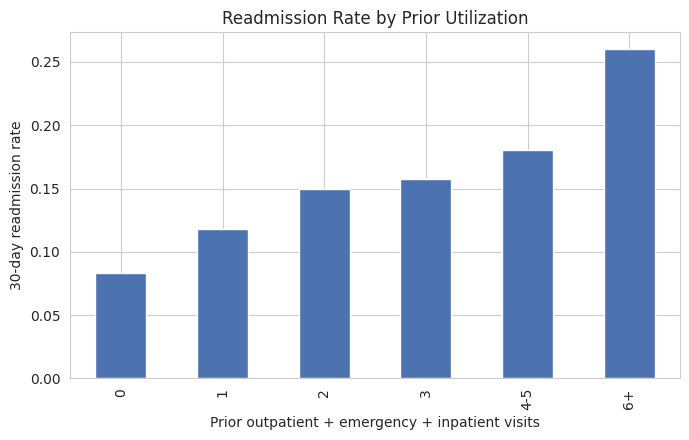

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bucket = pd.cut(clean["total_prior_visits"], [-1, 0, 1, 2, 3, 5, 100], labels=["0", "1", "2", "3", "4-5", "6+"])
rate = clean.groupby(bucket, observed=True)[TARGET].mean()
rate.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Prior outpatient + emergency + inpatient visits")
ax.set_ylabel("30-day readmission rate")
ax.set_title("Readmission Rate by Prior Utilization")
fig.tight_layout()
plt.show()

A patient with 6+ prior visits is readmitted within 30 days at roughly **3x** the rate of a patient with none — utilization history is doing a lot of the work here, consistent with how readmission-risk models are described in the clinical literature.

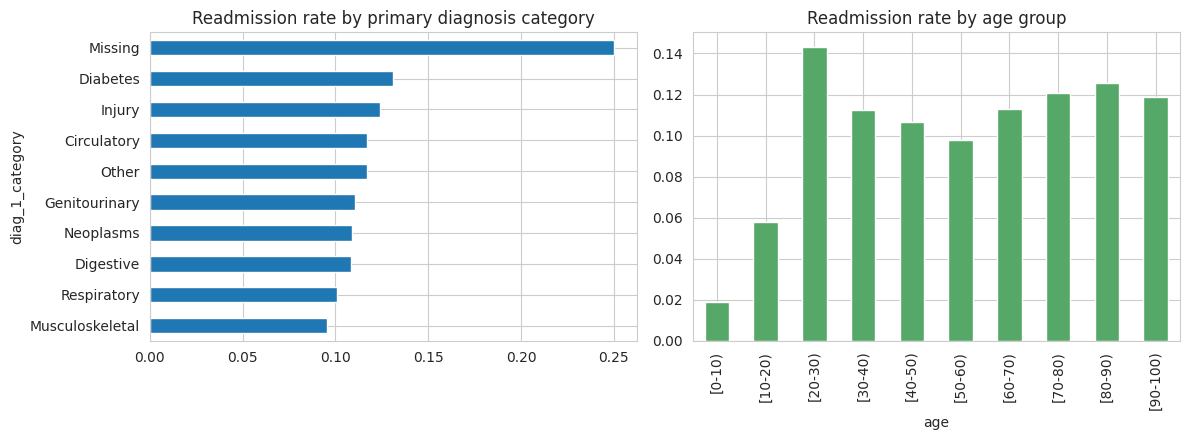

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clean.groupby("diag_1_category", observed=True)[TARGET].mean().sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Readmission rate by primary diagnosis category")
clean.groupby("age", observed=True)[TARGET].mean().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Readmission rate by age group")
fig.tight_layout()
plt.show()

## 5. Modeling, evaluation, and fairness

Full training pipeline lives in `src/train.py`: a class-weighted logistic regression baseline vs. an XGBoost model with native categorical support, evaluated on a **patient-level** held-out split (no patient's encounters appear in both train and test). Race is deliberately excluded from the model's features — see the module docstring in `src/train.py` for why — but checked post-hoc for fairness.

In [10]:
import json
with open("../models/metrics.json") as f:
    metrics = json.load(f)
pd.DataFrame({k: v for k, v in metrics.items() if k != "fairness_by_race_group"}).T

,roc_auc,pr_auc,confusion_matrix_at_0.5,top_decile_capture_rate,top_quintile_capture_rate
logistic_regression,0.6684,0.2199,"{'true_negative': 15207, 'false_positive': 676...",NaN,NaN
xgboost,0.6752,0.2316,"{'true_negative': 15608, 'false_positive': 636...",0.2528,0.4034


**ROC-AUC of ~0.68 is the honest result for this task, not a shortcoming to explain away.** Predicting a 30-day hospital readmission from administrative/encounter data is a genuinely hard problem — it depends heavily on social factors (housing stability, caregiver support, medication adherence) that simply aren't in this dataset. Published academic and Kaggle analyses of this exact dataset land in the same 0.65-0.70 AUC range; a model claiming 0.90+ on this task would be a red flag for leakage, not a better model. What actually matters for the care-management use case is ranking, not raw discrimination:

In [11]:
print(f"Top-decile capture rate: {metrics['xgboost']['top_decile_capture_rate']:.0%} of readmissions caught by flagging the riskiest 10% of discharges")
print(f"Top-quintile capture rate: {metrics['xgboost']['top_quintile_capture_rate']:.0%} of readmissions caught by flagging the riskiest 20% of discharges")

Top-decile capture rate: 25% of readmissions caught by flagging the riskiest 10% of discharges
Top-quintile capture rate: 40% of readmissions caught by flagging the riskiest 20% of discharges


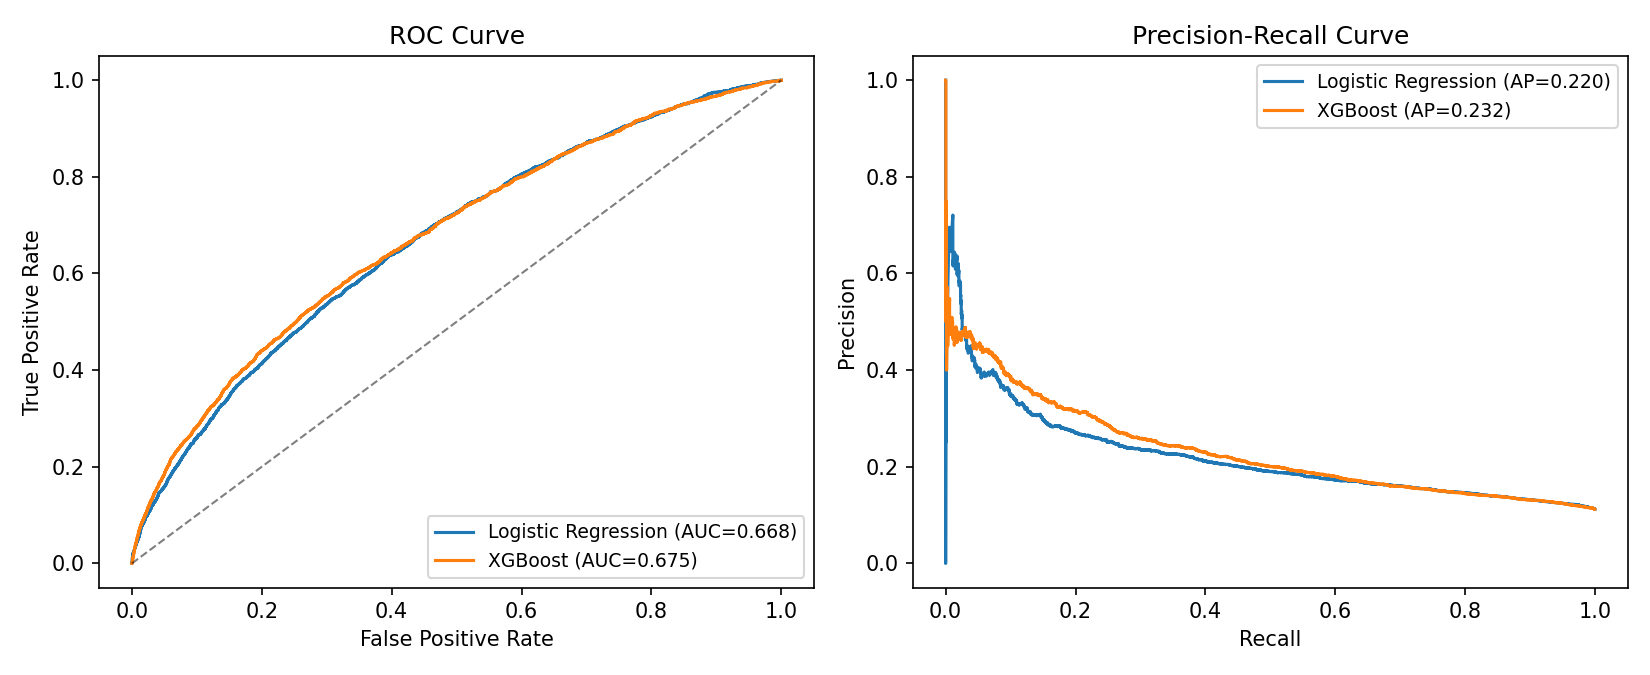

In [12]:
from IPython.display import Image
Image("../reports/figures/roc_pr_curves.png")

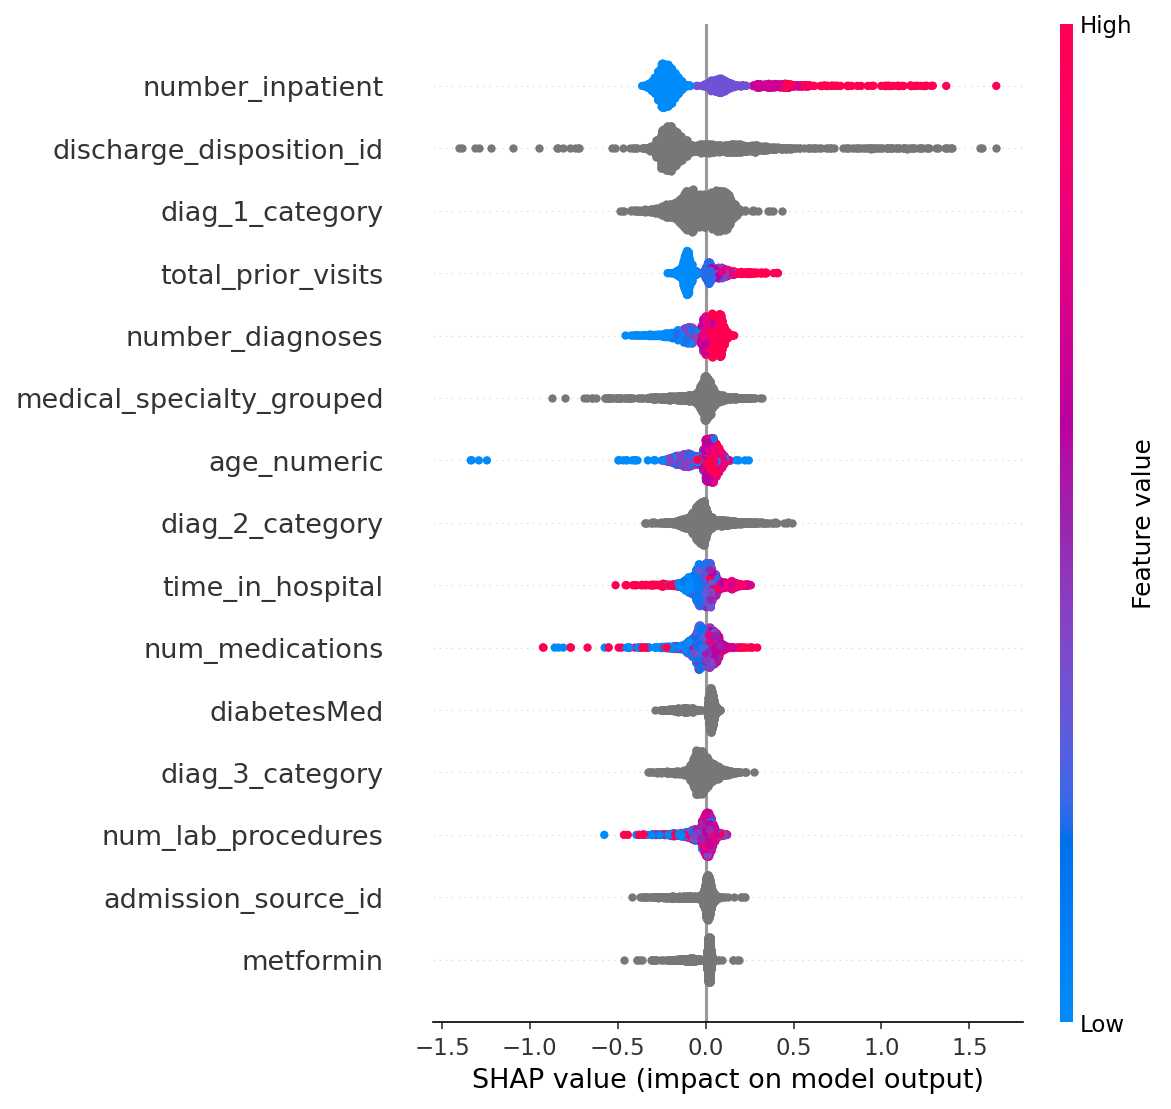

In [13]:
Image("../reports/figures/shap_summary.png")

SHAP confirms prior inpatient visits, discharge disposition, and primary diagnosis dominate the prediction — all clinically sensible, and consistent with the EDA above.

### Fairness check

In [14]:
pd.DataFrame(metrics["fairness_by_race_group"]).T

,n,actual_readmit_rate,predicted_positive_rate,recall,roc_auc
AfricanAmerican,4607.0,0.1083,0.3286,0.5210,0.6593
Asian,158.0,0.0949,0.2595,0.4667,0.6620
Caucasian,18563.0,0.1153,0.3209,0.5502,0.6778
Hispanic,507.0,0.0966,0.2742,0.5714,0.7440
Other,361.0,0.1108,0.2493,0.4750,0.6607
Unknown,561.0,0.0802,0.2299,0.4000,0.6305


Recall and predicted-positive rate move together fairly closely across race groups (with more noise in the smaller groups, as expected from sample size alone), and per-group AUC stays in a similar band to the overall model. This isn't a substitute for a full fairness audit before any real deployment, but it's the kind of check that should run *before* a model like this goes anywhere near a live workflow — and it's the reason race was excluded from the features in the first place rather than left in because it "improved AUC." 